In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

# 1. 데이터 생성
- 남여 키와 몸무게 데이터를 군집화

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [15]:
random.randint(140 ,195)

144

In [17]:
data = []
for i in range(50):
    # 여자 데이터(몸무게와 키) 추가
    data.append([random.randint(40, 70), random.randint(140, 170)])
    # 남자 데이터(몸무게와 키) 추가
    data.append([random.randint(60, 95), random.randint(160, 195)])

In [25]:
print('여자 몸무게(x축) :', [female[0] for female in data[::2]])
print('여자 키(y축) :', [female[1] for female in data[::2]])

print('남자 몸무게(x축) :', [male[0] for male in data[1::2]])
print('남자 키(y축) :', [male[1] for male in data[1::2]])

여자 몸무게(x축) : [50, 67, 54, 65, 68, 40, 52, 45, 61, 51, 51, 40, 57, 63, 44, 63, 61, 51, 65, 44, 59, 52, 47, 45, 51, 45, 44, 46, 66, 59, 64, 70, 69, 40, 52, 45, 58, 52, 59, 66, 46, 41, 57, 44, 70, 70, 62, 57, 41, 53]
여자 키(y축) : [167, 170, 148, 144, 155, 141, 148, 161, 166, 144, 145, 145, 142, 156, 157, 147, 165, 149, 165, 154, 166, 148, 151, 152, 147, 170, 156, 163, 143, 167, 147, 164, 168, 160, 165, 143, 161, 149, 150, 155, 141, 161, 160, 151, 145, 146, 152, 165, 170, 153]
남자 몸무게(x축) : [90, 84, 71, 87, 84, 64, 92, 63, 87, 95, 95, 87, 78, 88, 89, 64, 89, 70, 75, 91, 93, 62, 88, 91, 84, 88, 70, 81, 65, 76, 94, 82, 94, 91, 76, 87, 85, 73, 81, 60, 87, 93, 86, 89, 86, 76, 80, 85, 64, 76]
남자 키(y축) : [194, 171, 194, 166, 195, 160, 168, 161, 160, 167, 167, 189, 178, 193, 163, 189, 189, 184, 160, 181, 190, 177, 181, 161, 178, 165, 177, 189, 166, 193, 195, 180, 193, 167, 183, 195, 178, 171, 175, 182, 168, 194, 166, 191, 181, 169, 191, 174, 161, 173]


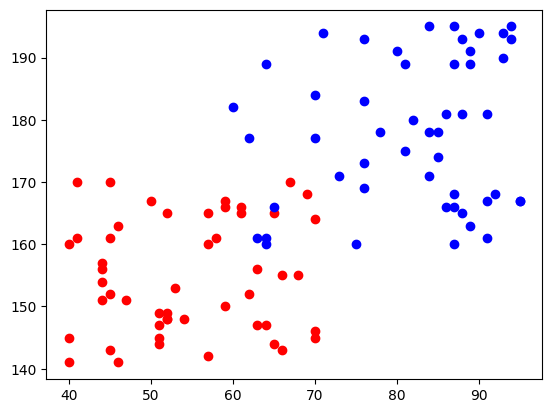

In [28]:
plt.plot([female[0] for female in data[::2]],
         [female[1] for female in data[::2]], 'o', color='r')
plt.plot([male[0] for male in data[1::2]],
         [male[1] for male in data[1::2]], 'o', color='b')
plt.show()

# 2. 군집화 로직

In [37]:
# 초기 랜덤 지점 2개
random_points = [
    [random.randint(40,90), random.randint(140,195)],
    [random.randint(40,90), random.randint(140,195)]
]
random_points[0], random_points[1] 

([55, 186], [42, 150])

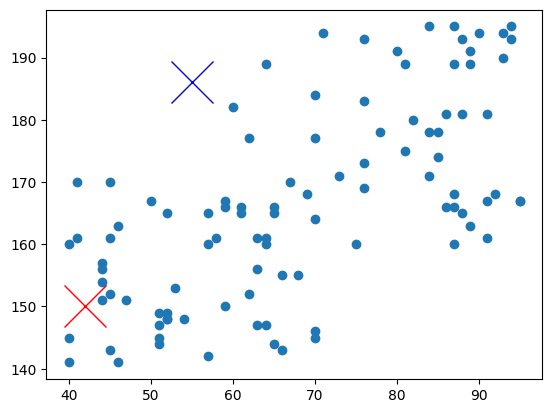

In [42]:
plt.plot([d[0] for d in data],
         [d[1] for d in data], 'o')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b') # 기준점 0
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r') # 기준점 1

In [45]:
# 두점 거리를 return하는 함수 점은 [50, 160]
def dist(a, b):
    return np.sqrt( (a[0]-b[0])**2 + (a[1]-b[1])**2 )
print(dist([3,4], [0,0]))
print(dist([5,7], [-1,-1]))

5.0
10.0


In [48]:
# random_points[0]에 가까운 그룹(group0)과 random_points[1]에 가까운 그룹(group1)을 분류
group0 = []
group1 = []
for d in data:
    if dist(random_points[0], d) < dist(random_points[1], d):
        group0.append(d)
    else:
        group1.append(d)
len(group0), len(group1)

(57, 43)

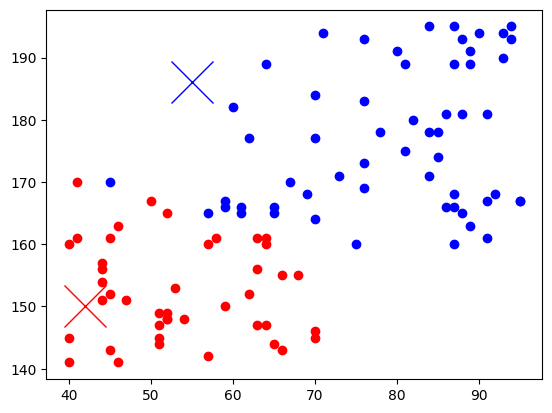

In [52]:
# group0과 group1, random_points[0]과 random_points[1]
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')
plt.show()

In [57]:
# group0과 group1 중심점으로 기준점을 이동
group0_meanX = np.mean([d[0] for d in group0])
group0_meanY = np.mean([d[1] for d in group0])
random_points[0] = [group0_meanX, group0_meanY]

group1_meanX = np.mean([d[0] for d in group1])
group1_meanY = np.mean([d[1] for d in group1])
random_points[1] = [group1_meanX, group1_meanY]
random_points

[[79.08771929824562, 176.78947368421052],
 [53.48837209302326, 152.41860465116278]]

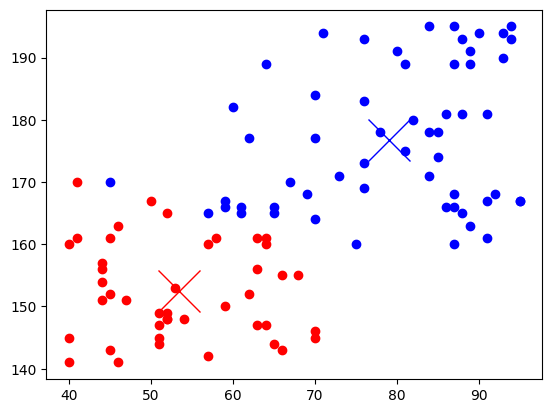

In [58]:
plt.plot([d[0] for d in group0], [d[1] for d in group0], 'o', color='b')
plt.plot([d[0] for d in group1], [d[1] for d in group1], 'o', color='r')
plt.plot(random_points[0][0], random_points[0][1], 'x', markersize=30, color='b')
plt.plot(random_points[1][0], random_points[1][1], 'x', markersize=30, color='r')
plt.show()